Data Transformation

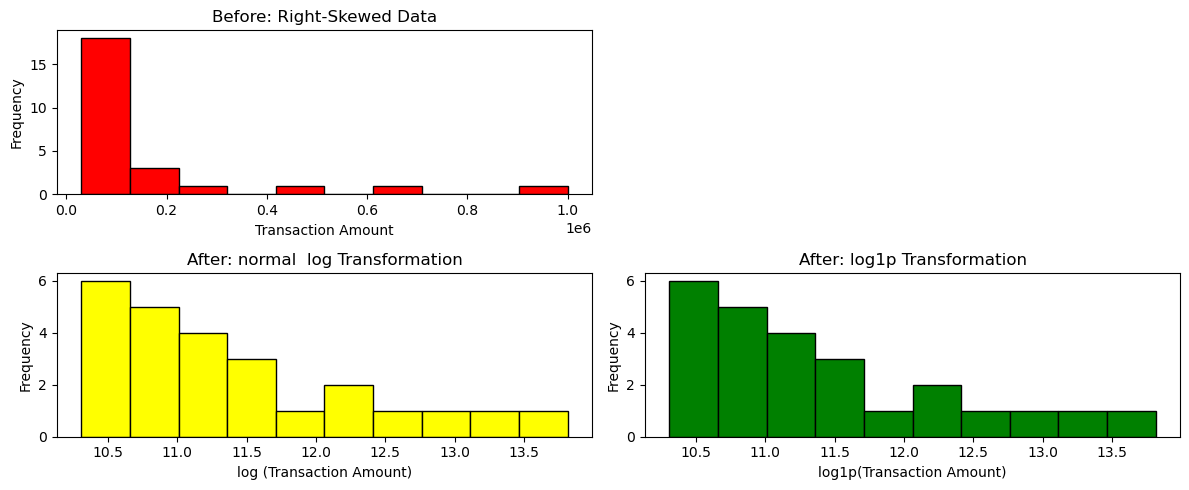

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# np.random.seed(42)
# data = np.random.exponential(scale=100, size=1000)

df = pd.DataFrame({
    "salary": [
        30000, 32000, 35000, 38000, 40000,
        42000, 45000, 48000, 50000, 55000,
        60000, 65000, 70000, 75000, 80000,
        90000, 100000, 120000, 150000, 180000,
        220000, 300000, 450000, 700000, 1000000
    ]
})


normal_log = np.log(df)

log_data = np.log1p(df)
# log1p usage: 1 add karne ki wajah: agar x = 0 ho, to normal log(0) undefined hota hai. log1p(0) safely 0 deta hai.
plt.figure(figsize=(12, 5))

# BEFORE
plt.subplot(2, 2, 1)
plt.hist(df, bins=10, color="red", edgecolor="black")
plt.title("Before: Right-Skewed Data")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

# BEFORE
plt.subplot(2, 2, 3)
plt.hist(normal_log, bins=10, color="yellow", edgecolor="black")
plt.title("After: normal  log Transformation")
plt.xlabel("log (Transaction Amount)")
plt.ylabel("Frequency")

# AFTER
plt.subplot(2, 2, 4)
plt.hist(log_data, bins=10, color="green", edgecolor="black")
plt.title("After: log1p Transformation")
plt.xlabel("log1p(Transaction Amount)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Log Transformation: Log transformation mein hum numerical data ki large values ko compress (chhota) karte hain taa-ke right-skewness aur extreme values ka effect kam ho, aur ML model ke liye data ko handle karna easier ho.
# Hum sirf number chhota karne ke liye log nahi lagate. Asal faida data ki distribution ko improve karna hai.
# Before:
# 10, 20, 50, 100, 500, 1,000, 10,000, 100,000
                        #   ↑
                        #  bohat large
                        #  in data pr galat impact parta hain
                        # is leya transform kar ky asa kar detay hain 
# After:
# 2.4, 3.0, 3.9, 4.6, 6.2, 6.9, 9.2, 11.5

In [15]:
df["sqrt_salary"] = np.sqrt(df["salary"])
print(df)

     salary  sqrt_salary
0     30000   173.205081
1     32000   178.885438
2     35000   187.082869
3     38000   194.935887
4     40000   200.000000
5     42000   204.939015
6     45000   212.132034
7     48000   219.089023
8     50000   223.606798
9     55000   234.520788
10    60000   244.948974
11    65000   254.950976
12    70000   264.575131
13    75000   273.861279
14    80000   282.842712
15    90000   300.000000
16   100000   316.227766
17   120000   346.410162
18   150000   387.298335
19   180000   424.264069
20   220000   469.041576
21   300000   547.722558
22   450000   670.820393
23   700000   836.660027
24  1000000  1000.000000


In [16]:
df["cbrt_salary"] = np.cbrt(df["salary"])

print(df)

     salary  sqrt_salary  cbrt_salary
0     30000   173.205081    31.072325
1     32000   178.885438    31.748021
2     35000   187.082869    32.710663
3     38000   194.935887    33.619754
4     40000   200.000000    34.199519
5     42000   204.939015    34.760266
6     45000   212.132034    35.568933
7     48000   219.089023    36.342412
8     50000   223.606798    36.840315
9     55000   234.520788    38.029525
10    60000   244.948974    39.148676
11    65000   254.950976    40.207258
12    70000   264.575131    41.212853
13    75000   273.861279    42.171633
14    80000   282.842712    43.088694
15    90000   300.000000    44.814047
16   100000   316.227766    46.415888
17   120000   346.410162    49.324241
18   150000   387.298335    53.132928
19   180000   424.264069    56.462162
20   220000   469.041576    60.368107
21   300000   547.722558    66.943295
22   450000   670.820393    76.630943
23   700000   836.660027    88.790400
24  1000000  1000.000000   100.000000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["standard_salary"] = scaler.fit_transform(
    df[["salary"]]
)

print(df)

     salary  sqrt_salary  cbrt_salary  standard_salary
0     30000   173.205081    31.072325        -0.584000
1     32000   178.885438    31.748021        -0.575218
2     35000   187.082869    32.710663        -0.562045
3     38000   194.935887    33.619754        -0.548872
4     40000   200.000000    34.199519        -0.540090
5     42000   204.939015    34.760266        -0.531308
6     45000   212.132034    35.568933        -0.518135
7     48000   219.089023    36.342412        -0.504962
8     50000   223.606798    36.840315        -0.496180
9     55000   234.520788    38.029525        -0.474225
10    60000   244.948974    39.148676        -0.452270
11    65000   254.950976    40.207258        -0.430316
12    70000   264.575131    41.212853        -0.408361
13    75000   273.861279    42.171633        -0.386406
14    80000   282.842712    43.088694        -0.364451
15    90000   300.000000    44.814047        -0.320541
16   100000   316.227766    46.415888        -0.276631
17   12000

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["minmax_salary"] = scaler.fit_transform(
    df[["salary"]]
)

print(df)

     salary  sqrt_salary  cbrt_salary  standard_salary  minmax_salary
0     30000   173.205081    31.072325        -0.584000       0.000000
1     32000   178.885438    31.748021        -0.575218       0.002062
2     35000   187.082869    32.710663        -0.562045       0.005155
3     38000   194.935887    33.619754        -0.548872       0.008247
4     40000   200.000000    34.199519        -0.540090       0.010309
5     42000   204.939015    34.760266        -0.531308       0.012371
6     45000   212.132034    35.568933        -0.518135       0.015464
7     48000   219.089023    36.342412        -0.504962       0.018557
8     50000   223.606798    36.840315        -0.496180       0.020619
9     55000   234.520788    38.029525        -0.474225       0.025773
10    60000   244.948974    39.148676        -0.452270       0.030928
11    65000   254.950976    40.207258        -0.430316       0.036082
12    70000   264.575131    41.212853        -0.408361       0.041237
13    75000   273.86

In [25]:
from sklearn.preprocessing import RobustScaler

RScalar = RobustScaler()

df["Robust Scalar"] = RScalar.fit_transform(
    df[["salary"]]
)

print(df[["salary","Robust Scalar"]])

     salary  Robust Scalar
0     30000      -0.380952
1     32000      -0.361905
2     35000      -0.333333
3     38000      -0.304762
4     40000      -0.285714
5     42000      -0.266667
6     45000      -0.238095
7     48000      -0.209524
8     50000      -0.190476
9     55000      -0.142857
10    60000      -0.095238
11    65000      -0.047619
12    70000       0.000000
13    75000       0.047619
14    80000       0.095238
15    90000       0.190476
16   100000       0.285714
17   120000       0.476190
18   150000       0.761905
19   180000       1.047619
20   220000       1.428571
21   300000       2.190476
22   450000       3.619048
23   700000       6.000000
24  1000000       8.857143


In [32]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df["yeo-johnson"] = pt.fit_transform(
    df[["salary"]]
)

print(df[["salary", "yeo-johnson"]])
# Yeo-Johnson transformation ek power transformation technique hai jo data ki skewness ko reduce karke uski distribution ko more symmetric banane ki koshish karti hai, aur iska major advantage ye hai ke ye positive, zero aur negative values par bhi kaam kar sakti hai.

     salary  yeo-johnson
0     30000    -1.632881
1     32000    -1.485087
2     35000    -1.288982
3     38000    -1.117910
4     40000    -1.015336
5     42000    -0.920605
6     45000    -0.791218
7     48000    -0.674858
8     50000    -0.603512
9     55000    -0.443473
10    60000    -0.305021
11    65000    -0.183781
12    70000    -0.076520
13    75000     0.019209
14    80000     0.105300
15    90000     0.254212
16   100000     0.378930
17   120000     0.577257
18   150000     0.792686
19   180000     0.948829
20   220000     1.102347
21   300000     1.306605
22   450000     1.523041
23   700000     1.706825
24  1000000     1.823942


In [33]:
pt = PowerTransformer(method="box-cox")

df["box-cox"] = pt.fit_transform(
    df[["salary"]]
)

print(df[["salary","box-cox"]])
# Box-Cox ke liye data positive hona chahiye.
# zero negative handle ni hote 
# Box-Cox = Yeo-Johnson ka less flexible version samajh lo, kyunki Box-Cox ki condition hai: data strictly positive hona chahiye.

     salary   box-cox
0     30000 -1.632888
1     32000 -1.485091
2     35000 -1.288984
3     38000 -1.117910
4     40000 -1.015335
5     42000 -0.920604
6     45000 -0.791216
7     48000 -0.674856
8     50000 -0.603510
9     55000 -0.443471
10    60000 -0.305018
11    65000 -0.183778
12    70000 -0.076518
13    75000  0.019211
14    80000  0.105302
15    90000  0.254213
16   100000  0.378931
17   120000  0.577257
18   150000  0.792685
19   180000  0.948827
20   220000  1.102344
21   300000  1.306603
22   450000  1.523039
23   700000  1.706824
24  1000000  1.823943


c:\Users\Tech Mart\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (25). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Tech Mart\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (25). n_quantiles is set to n_samples.
  warnings.warn(


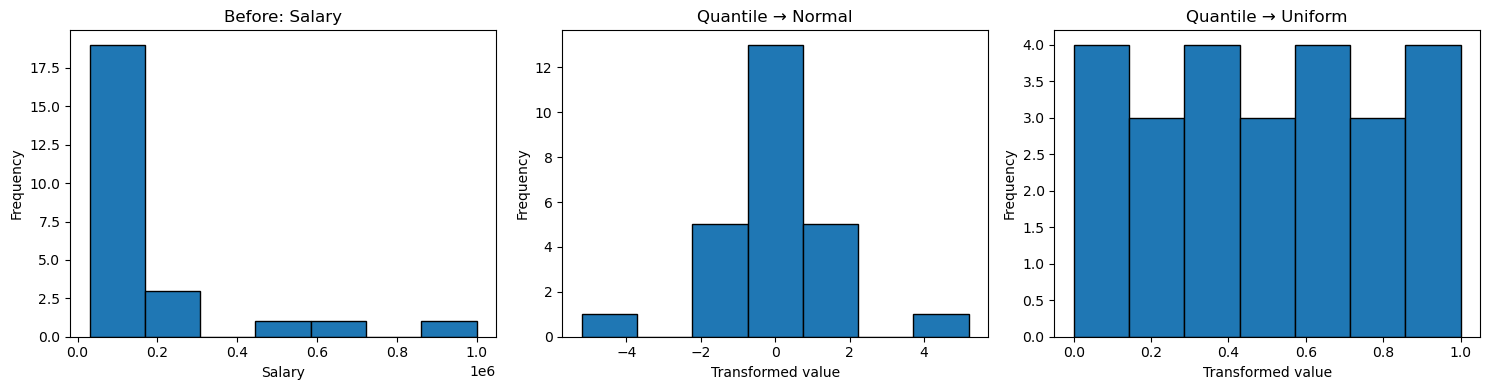

In [41]:
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt

qt_uniform = QuantileTransformer(
    output_distribution="uniform"
)
df["quantile_uniform"] = qt_uniform.fit_transform(
    df[["salary"]]
)
# uniform:
# Agar tum chahte ho transformed values approximately equal spread mein hon:


qt_normal = QuantileTransformer(
    output_distribution="normal",
    random_state=42
)
df["quantile_normal"] = qt_normal.fit_transform(
    df[["salary"]]
)
# Normal:
# Center mein values zyada hoti hain aur dono sides par values gradually kam hoti hain.
# Normal use karne ka simple reason: jab tumhe feature ko approximately Gaussian/bell-shaped banana ho, especially jab downstream method/model ki assumptions ya behavior is shape se benefit kare.



plt.figure(figsize=(15, 4))

# Original
plt.subplot(1, 3, 1)
plt.hist(df["salary"], bins=7, edgecolor="black")
plt.title("Before: Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")

# Normal
plt.subplot(1, 3, 2)
plt.hist(df["quantile_normal"], bins=7, edgecolor="black")
plt.title("Quantile → Normal")
plt.xlabel("Transformed value")
plt.ylabel("Frequency")

# Uniform
plt.subplot(1, 3, 3)
plt.hist(df["quantile_uniform"], bins=7, edgecolor="black")
plt.title("Quantile → Uniform")
plt.xlabel("Transformed value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Agar data bohat zyada skewed hai aur tum usko specific distribution, especially normal distribution, mein map karna chahte ho, to Quantile Transformer useful ho sakta hai.
# Quantile Transformer dono types ki skewness ko handle kar sakta hai.

# Normal transformations jaise log/Yeo-Johnson shape ko modify karte hain.
# Quantile Transformer basically data ki rank/percentile dekhta hai:
# Is wajah se extreme skewness ko kaafi aggressively reduce kar sakta hai.

normalization kb use hogi. or main aksar minmaxscaler ya L1 ya L2
Standardization kb use hogi. or main aksar StanderScaler 
Ye zyada tar model aur data par depend karta hai. jo hum algorithm use kar kary hain os ky leya kya suitable rahe ga 

agar feature categorical hain tu encodeding kary gay jis main (lable_endording on_hot_encoding OrdinalEncoder BinaryEncoder frequency_encoding)

agar feature numerical hain tu scalerization ya normalization ya transform  kary gay jis main hum scalerization( StandardScaler, MinMaxScaler, RobustScaler, ... ) normalization(L1, L2, log, ...) transform(box-cox, yeo-johnson, QuantileTransformer , ...)


In [6]:
from sklearn.preprocessing import Normalizer
Normalizer_L2 = Normalizer(norm='l2')
Normalizer_L1 = Normalizer(norm='l1')
df['norm_l2'] = Normalizer_L2.fit_transform(df[['salary']])
df['norm_l1'] = Normalizer_L1.fit_transform(df[['salary']])
print(df[['salary', 'norm_l2', "norm_l1"]])

# agar ak feature ho tu 1 he hoga Q ky l1 ho ya l2 dono one kar de gay Q ky is dono formula he kuch asa hain ya ak se zeyda feature pr kam karta hain

# formula l1 = x / ​∣ x ∣ 
# formula l2 = x / √x² 

     salary  norm_l2  norm_l1
0     30000      1.0      1.0
1     32000      1.0      1.0
2     35000      1.0      1.0
3     38000      1.0      1.0
4     40000      1.0      1.0
5     42000      1.0      1.0
6     45000      1.0      1.0
7     48000      1.0      1.0
8     50000      1.0      1.0
9     55000      1.0      1.0
10    60000      1.0      1.0
11    65000      1.0      1.0
12    70000      1.0      1.0
13    75000      1.0      1.0
14    80000      1.0      1.0
15    90000      1.0      1.0
16   100000      1.0      1.0
17   120000      1.0      1.0
18   150000      1.0      1.0
19   180000      1.0      1.0
20   220000      1.0      1.0
21   300000      1.0      1.0
22   450000      1.0      1.0
23   700000      1.0      1.0
24  1000000      1.0      1.0


In [9]:
import pandas as pd
from sklearn.preprocessing import Normalizer

df = pd.DataFrame({
    'salary': [30000, 50000, 100000],
    'bonus': [5000, 10000, 20000],
    'experience': [2, 5, 10]
})

# L1 Normalization
normalizer_l1 = Normalizer(norm='l1')
df_l1 = normalizer_l1.fit_transform(df)

# L2 Normalization
normalizer_l2 = Normalizer(norm='l2')
df_l2 = normalizer_l2.fit_transform(df)

print("Original Data:")
print(df)

print("\nL1 Normalized:")
print(df_l1)

print("\nL2 Normalized:")
print(df_l2)

# l1 = 30000 / 3000 + 5000 + 2 = 0.85 
# l2 = 30000 / √3000² + 5000² + 2² = 0.98

Original Data:
   salary  bonus  experience
0   30000   5000           2
1   50000  10000           5
2  100000  20000          10

L1 Normalized:
[[8.57093880e-01 1.42848980e-01 5.71395920e-05]
 [8.33263895e-01 1.66652779e-01 8.33263895e-05]
 [8.33263895e-01 1.66652779e-01 8.33263895e-05]]

L2 Normalized:
[[9.86393922e-01 1.64398987e-01 6.57595948e-05]
 [9.80580671e-01 1.96116134e-01 9.80580671e-05]
 [9.80580671e-01 1.96116134e-01 9.80580671e-05]]
